**Part III: Language Tasks — Spam vs Ham SMS Classification**

## Required Libraries


In [ ]:
!pip install numpy==1.23.5 -q
!pip install gensim -q
!pip install wordcloud -q
!pip install gradio -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.7/10.7 MB 42.8 MB/s eta 0:00:00
  Installing build dependencies ... done
  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Getting requirements to build wheel ... error
error: subprocess-exited-with-error

× Getting requirements to build wheel did not run successfully.
│ exit code: 1
╰─> See above for output.

note: This error originates from a subprocess, and is likely not a problem with pip.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 76.6 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')
print("Google Drive mounted successfully.")

Mounted at /content/drive
Google Drive mounted successfully.


## Import Libraries

In [ ]:
# Standard & Data Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import zipfile
import os
import time
import warnings
warnings.filterwarnings('ignore')

# NLP / Text Processing
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('wordnet',   quiet=True)
nltk.download('omw-1.4',   quiet=True)
from nltk.corpus import stopwords
from nltk.stem  import WordNetLemmatizer
from wordcloud  import WordCloud
from collections import Counter

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, ConfusionMatrixDisplay
)

# Keras / TensorFlow
import tensorflow as tf
from tensorflow.keras.preprocessing.text     import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models   import Sequential
from tensorflow.keras.layers   import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# Gensim (GloVe / Word2Vec)
import gensim.downloader as api

print("All libraries imported successfully.")
print(f"TensorFlow version : {tf.__version__}")

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

All libraries imported successfully.
TensorFlow version : 2.19.0


---
## Text Preprocessing, Tokenization, and Sequence Padding

In [ ]:
# Path to ZIP file on Google Drive
ZIP_PATH    = '/content/drive/MyDrive/Bipin/AIML/Spam vs Ham Sms Dataset-20260424T044344Z-3-001.zip'
EXTRACT_DIR = '/content/spam_dataset/'

# Create extraction directory
os.makedirs(EXTRACT_DIR, exist_ok=True)

# Extract the ZIP file
with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
    zf.extractall(EXTRACT_DIR)
    extracted_files = zf.namelist()

print("Files extracted from ZIP:")
for f in extracted_files:
    print(f"  {f}")

# Auto-detect the CSV inside the extracted folder
csv_path = None
for root, dirs, files in os.walk(EXTRACT_DIR):
    for fname in files:
        if fname.endswith('.csv'):
            csv_path = os.path.join(root, fname)
            break

if csv_path is None:
    raise FileNotFoundError("No CSV file found in ZIP. Please check the archive contents.")

print(f"\nCSV found at: {csv_path}")

Files extracted from ZIP:
  9.Spam vs Ham Sms Dataset/spamvsham.csv
  9.Spam vs Ham Sms Dataset/9.Description Spam Vs. Ham Dataset.txt

CSV found at: /content/spam_dataset/9.Spam vs Ham Sms Dataset/spamvsham.csv


In [ ]:
# Load CSV with Pandas
df = pd.read_csv(
    csv_path,
    encoding='latin-1',
    usecols=[0, 1],
    names=['label', 'message'],
    header=0
)

# Drop NaN rows if any
df.dropna(subset=['label', 'message'], inplace=True)
df.reset_index(drop=True, inplace=True)

print(f"Dataset shape  : {df.shape}")
print(f"Column names   : {df.columns.tolist()}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape  : (5572, 2)
Column names   : ['label', 'message']

First 5 rows:


,label,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [ ]:
print("=" * 55)
print("DATASET DESCRIPTION")
print("=" * 55)
print(f"Source         : SMS Spam Collection Dataset")
print(f"Total Samples  : {len(df)}")
print(f"Classes        : {df['label'].unique().tolist()}")
print(f"Missing Values : {df.isnull().sum().sum()}")

class_counts = df['label'].value_counts()
print(f"\nClass Distribution:")
print(class_counts)
print(f"\nSpam % : {class_counts['spam'] / len(df) * 100:.2f}%")
print(f"Ham  % : {class_counts['ham']  / len(df) * 100:.2f}%")

df['msg_length'] = df['message'].apply(len)
print(f"\nMessage Length Statistics (by class):")
print(df.groupby('label')['msg_length'].describe().round(2))

DATASET DESCRIPTION
Source         : SMS Spam Collection Dataset
Total Samples  : 5572
Classes        : ['ham', 'spam']
Missing Values : 0

Class Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Spam % : 13.41%
Ham  % : 86.59%

Message Length Statistics (by class):
        count    mean    std   min    25%    50%    75%    max
label                                                         
ham    4825.0   71.02  58.02   2.0   33.0   52.0   92.0  910.0
spam    747.0  138.87  29.18  13.0  132.5  149.0  157.0  224.0


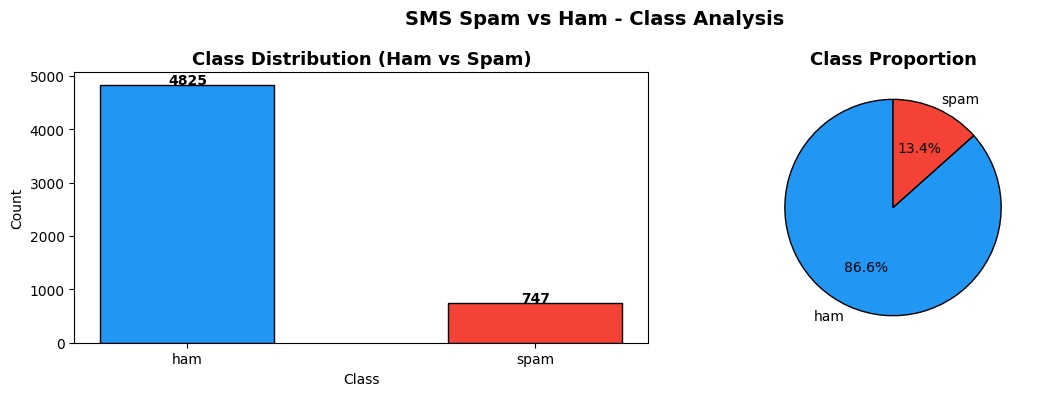

In [ ]:
# Class distribution plots
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
colors = ['#2196F3', '#F44336']

axes[0].bar(class_counts.index, class_counts.values,
            color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution (Ham vs Spam)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
for i, v in enumerate(class_counts.values):
    axes[0].text(i, v + 20, str(v), ha='center', fontweight='bold')

axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Class Proportion', fontsize=13, fontweight='bold')

plt.suptitle('SMS Spam vs Ham - Class Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

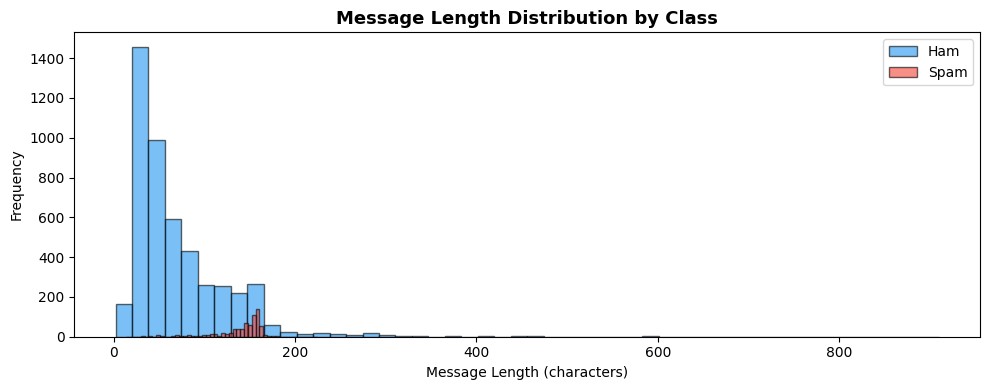

In [ ]:
# Message length distribution
fig, ax = plt.subplots(figsize=(10, 4))
for label, color in zip(['ham', 'spam'], ['#2196F3', '#F44336']):
    ax.hist(df[df['label'] == label]['msg_length'], bins=50,
            alpha=0.6, label=label.capitalize(),
            color=color, edgecolor='black')
ax.set_title('Message Length Distribution by Class', fontsize=13, fontweight='bold')
ax.set_xlabel('Message Length (characters)')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.savefig('msg_length_dist.png', dpi=150, bbox_inches='tight')
plt.show()

### Text Cleaning

In [ ]:
# Contraction mapping
CONTRACTIONS = {
    "don't": "do not",      "doesn't": "does not",   "didn't": "did not",
    "isn't": "is not",      "aren't": "are not",     "wasn't": "was not",
    "weren't": "were not",  "haven't": "have not",   "hasn't": "has not",
    "hadn't": "had not",    "won't": "will not",     "wouldn't": "would not",
    "can't": "cannot",      "couldn't": "could not", "shouldn't": "should not",
    "mightn't": "might not","mustn't": "must not",   "i'm": "i am",
    "i've": "i have",       "i'll": "i will",        "i'd": "i would",
    "you're": "you are",    "you've": "you have",    "you'll": "you will",
    "you'd": "you would",   "he's": "he is",         "she's": "she is",
    "it's": "it is",        "we're": "we are",       "we've": "we have",
    "they're": "they are",  "they've": "they have",  "that's": "that is",
    "there's": "there is",  "what's": "what is",     "let's": "let us",
}

STOP_WORDS = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def expand_contractions(text):
    for contraction, expansion in CONTRACTIONS.items():
        text = re.sub(re.escape(contraction), expansion, text)
    return text

def clean_text(text):
    """
    Full cleaning pipeline:
      1. Lowercase
      2. Expand contractions  (e.g. don't -> do not)
      3. Remove URLs
      4. Remove @mentions
      5. Remove #hashtags
      6. Remove numbers
      7. Remove punctuation
      8. Remove stopwords
      9. Lemmatize
    """
    text = text.lower()                                                   # 1
    text = expand_contractions(text)                                       # 2
    text = re.sub(r'http\S+|www\.\S+', '', text)                          # 3
    text = re.sub(r'@\w+', '', text)                                       # 4
    text = re.sub(r'#\w+', '', text)                                       # 5
    text = re.sub(r'\d+', '', text)                                        # 6
    text = text.translate(str.maketrans('', '', string.punctuation))       # 7
    tokens = text.split()
    tokens = [t for t in tokens if t not in STOP_WORDS]                   # 8
    tokens = [lemmatizer.lemmatize(t) for t in tokens]                    # 9
    return ' '.join(tokens)

df['cleaned_message'] = df['message'].apply(clean_text)

print("Sample Cleaning Results:")
print("=" * 70)
for i in range(3):
    print(f"[{df['label'].iloc[i].upper()}]")
    print(f"  BEFORE: {df['message'].iloc[i]}")
    print(f"  AFTER : {df['cleaned_message'].iloc[i]}")
    print()

Sample Cleaning Results:
[HAM]
  BEFORE: Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
  AFTER : go jurong point crazy available bugis n great world la e buffet cine got amore wat

[HAM]
  BEFORE: Ok lar... Joking wif u oni...
  AFTER : ok lar joking wif u oni

[SPAM]
  BEFORE: Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's
  AFTER : free entry wkly comp win fa cup final tkts st may text fa receive entry questionstd txt ratetcs apply over



### Visualize Cleaned Data

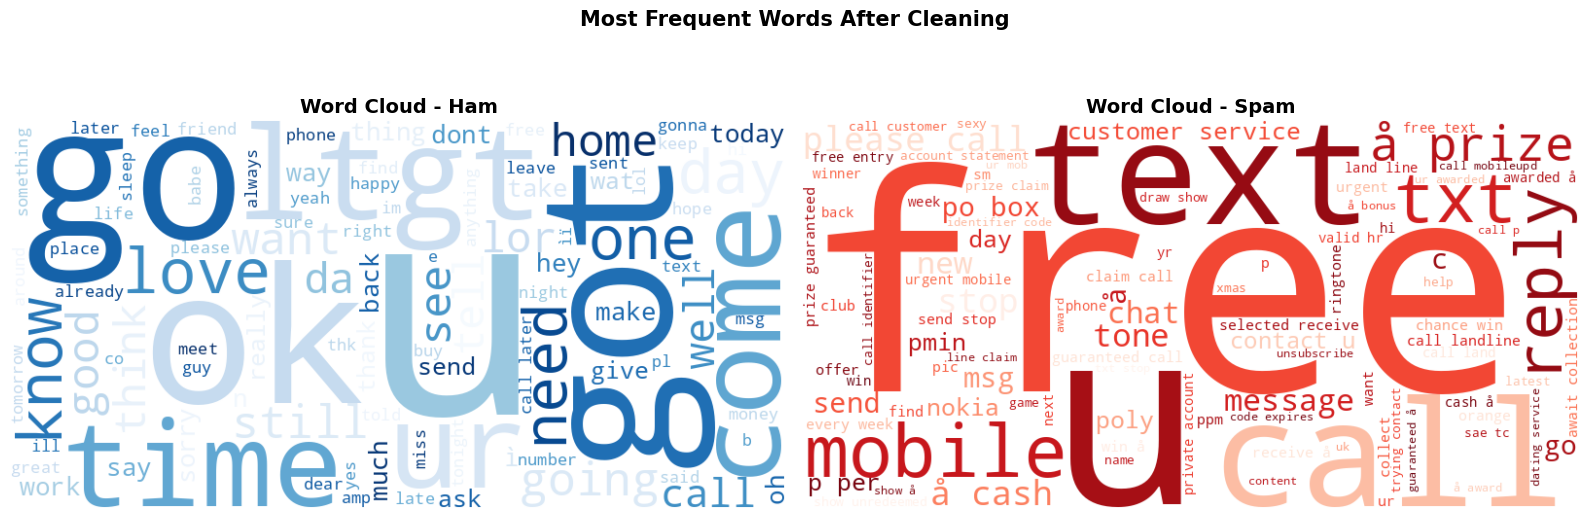

In [ ]:
# Word Cloud
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, cmap in zip(axes, ['ham', 'spam'], ['Blues', 'Reds']):
    corpus = ' '.join(df[df['label'] == label]['cleaned_message'])
    wc = WordCloud(width=800, height=400, background_color='white',
                   colormap=cmap, max_words=100).generate(corpus)
    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'Word Cloud - {label.capitalize()}', fontsize=14, fontweight='bold')
plt.suptitle('Most Frequent Words After Cleaning', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('wordcloud.png', dpi=150, bbox_inches='tight')
plt.show()

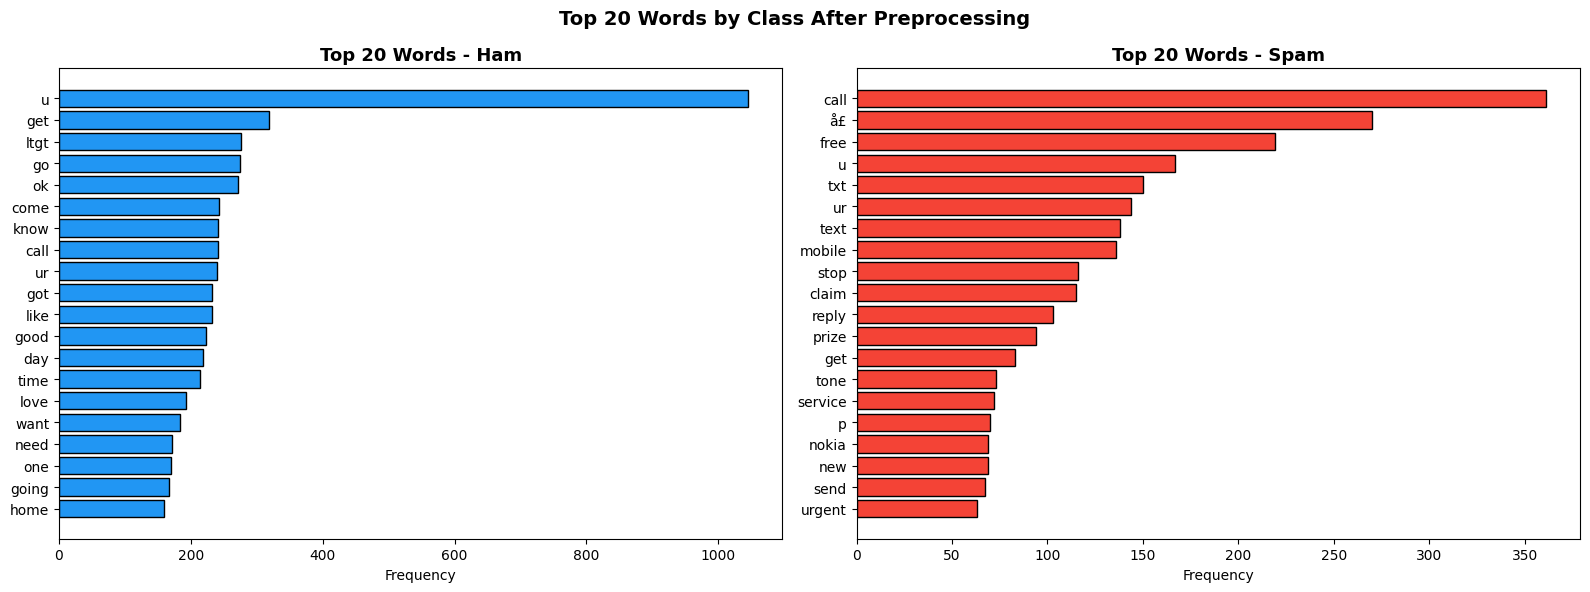

In [ ]:
# Top 20 Words per class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for ax, label, color in zip(axes, ['ham', 'spam'], ['#2196F3', '#F44336']):
    all_words = ' '.join(df[df['label'] == label]['cleaned_message']).split()
    freq = Counter(all_words).most_common(20)
    words, counts = zip(*freq)
    ax.barh(words[::-1], counts[::-1], color=color, edgecolor='black')
    ax.set_title(f'Top 20 Words - {label.capitalize()}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Frequency')
plt.suptitle('Top 20 Words by Class After Preprocessing', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('top_words.png', dpi=150, bbox_inches='tight')
plt.show()

### Label Encoding, Train/Test Split, Tokenization and Padding

In [ ]:
# Label Encoding: spam=1, ham=0
df['label_enc'] = df['label'].map({'spam': 1, 'ham': 0})
X = df['cleaned_message'].values
y = df['label_enc'].values

# Stratified 80/20 Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

print(f"Training samples : {len(X_train)}")
print(f"Testing  samples : {len(X_test)}")
print(f"Train spam ratio : {y_train.mean():.3f}")
print(f"Test  spam ratio : {y_test.mean():.3f}")

Training samples : 4457
Testing  samples : 1115
Train spam ratio : 0.134
Test  spam ratio : 0.134


In [ ]:
# Tokenization using Keras Tokenizer
VOCAB_SIZE = 10000
OOV_TOKEN  = '<OOV>'

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token=OOV_TOKEN)
tokenizer.fit_on_texts(X_train)   # Fit ONLY on training data to prevent leakage

word_index = tokenizer.word_index
vocab_size = min(VOCAB_SIZE, len(word_index)) + 1

train_seqs = tokenizer.texts_to_sequences(X_train)
test_seqs  = tokenizer.texts_to_sequences(X_test)

print(f"Total unique tokens : {len(word_index)}")
print(f"Effective vocab_size: {vocab_size}")
print(f"\nSample sequence     : {train_seqs[0][:10]} ...")

Total unique tokens : 6982
Effective vocab_size: 6983

Sample sequence     : [23, 228, 3141] ...


In [ ]:
# Percentile-Based Padding (95th percentile avoids excessively long sequences)
seq_lengths = [len(s) for s in train_seqs]
MAX_LEN     = int(np.percentile(seq_lengths, 95))

print("Sequence Length Statistics (Train):")
print(f"  Min             : {min(seq_lengths)}")
print(f"  Max             : {max(seq_lengths)}")
print(f"  Mean            : {np.mean(seq_lengths):.1f}")
print(f"  95th Percentile : {MAX_LEN}  <-- used as MAX_LEN")

X_train_pad = pad_sequences(train_seqs, maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(test_seqs,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train_pad shape : {X_train_pad.shape}")
print(f"X_test_pad  shape : {X_test_pad.shape}")

Sequence Length Statistics (Train):
  Min             : 0
  Max             : 79
  Mean            : 8.7
  95th Percentile : 20  <-- used as MAX_LEN

X_train_pad shape : (4457, 20)
X_test_pad  shape : (1115, 20)


---
## Model Building
### Shared Hyperparameters and Utility Functions

In [ ]:
EMBEDDING_DIM = 64
EPOCHS        = 20
BATCH_SIZE    = 64

def get_callbacks(patience=3):
    return [
        EarlyStopping(
            monitor='val_loss',
            patience=patience,
            restore_best_weights=True,
            verbose=1
        )
    ]

def plot_history(history, model_name, save_path=None):
    """Plot training vs validation loss and accuracy curves."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history.history['loss'],     label='Train Loss',      color='#2196F3')
    axes[0].plot(history.history['val_loss'], label='Validation Loss', color='#F44336', linestyle='--')
    axes[0].set_title(f'{model_name} - Loss Curve', fontweight='bold')
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss'); axes[0].legend()

    axes[1].plot(history.history['accuracy'],     label='Train Accuracy',      color='#4CAF50')
    axes[1].plot(history.history['val_accuracy'], label='Validation Accuracy', color='#FF9800', linestyle='--')
    axes[1].set_title(f'{model_name} - Accuracy Curve', fontweight='bold')
    axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

def evaluate_model(model, X_test, y_test, model_name):
    """Evaluate and print accuracy, confusion matrix, classification report."""
    y_prob = model.predict(X_test, verbose=0).flatten()
    y_pred = (y_prob >= 0.5).astype(int)
    acc    = accuracy_score(y_test, y_pred)

    print(f"\n{'='*55}")
    print(f"  {model_name} - Evaluation")
    print(f"{'='*55}")
    print(f"  Test Accuracy : {acc:.4f} ({acc*100:.2f}%)")
    print(f"\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam']))

    cm = confusion_matrix(y_test, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=['Ham', 'Spam']).plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{model_name}\nConfusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'cm_{model_name.replace(" ", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()

    return y_pred, acc

print("Helper functions ready.")

Helper functions ready.


---
### Simple RNN with Trainable Embedding Layer

In [ ]:
rnn_model = Sequential(name='SimpleRNN_Model')

rnn_model.add(Embedding(input_dim=vocab_size,
                        output_dim=EMBEDDING_DIM,
                        input_length=MAX_LEN,
                        name='embedding_rnn'))
rnn_model.add(SimpleRNN(64, return_sequences=False, name='simple_rnn'))
rnn_model.add(Dropout(0.4))
rnn_model.add(Dense(32, activation='relu', name='dense_hidden'))
rnn_model.add(Dropout(0.3))
rnn_model.add(Dense(1, activation='sigmoid', name='output'))

rnn_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
rnn_model.summary()

Model: "SimpleRNN_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_rnn (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training Model 1: Simple RNN...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 11s 54ms/step - accuracy: 0.9210 - loss: 0.2377 - val_accuracy: 0.9686 - val_loss: 0.1154
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9865 - loss: 0.0608 - val_accuracy: 0.9664 - val_loss: 0.1122
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9935 - loss: 0.0325 - val_accuracy: 0.9641 - val_loss: 0.1274
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9950 - loss: 0.0245 - val_accuracy: 0.9641 - val_loss: 0.1328
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9925 - loss: 0.0380 - val_accuracy: 0.9619 - val_loss: 0.1947
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

Training Time: 12.5s


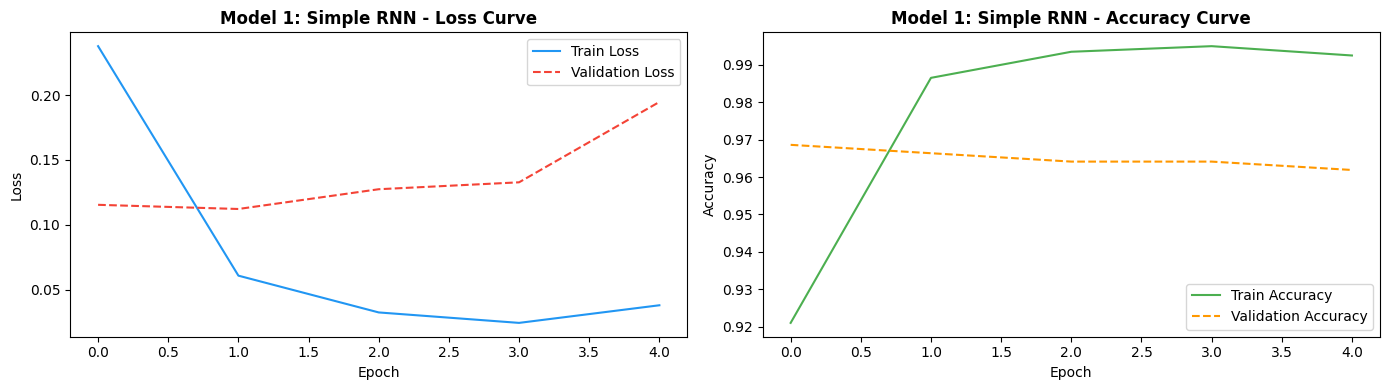

In [ ]:
print("Training Model 1: Simple RNN...")
t0 = time.time()

history_rnn = rnn_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=get_callbacks(patience=3),
    verbose=1
)

rnn_train_time = time.time() - t0
print(f"\nTraining Time: {rnn_train_time:.1f}s")
plot_history(history_rnn, 'Model 1: Simple RNN', save_path='history_rnn.png')


  Model 1: Simple RNN - Evaluation
  Test Accuracy : 0.9767 (97.67%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      0.99      0.99       966
        Spam       0.96      0.86      0.91       149

    accuracy                           0.98      1115
   macro avg       0.97      0.93      0.95      1115
weighted avg       0.98      0.98      0.98      1115



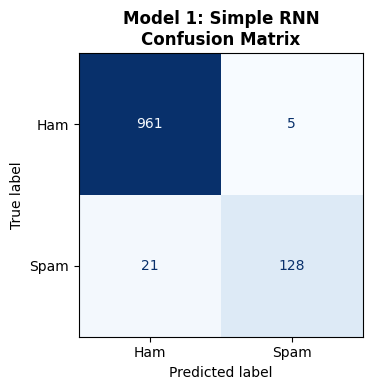

In [ ]:
y_pred_rnn, acc_rnn = evaluate_model(rnn_model, X_test_pad, y_test, 'Model 1: Simple RNN')

---
### LSTM with Trainable Embedding Layer

In [ ]:
lstm_model = Sequential(name='LSTM_Model')

lstm_model.add(Embedding(input_dim=vocab_size,
                         output_dim=EMBEDDING_DIM,
                         input_length=MAX_LEN,
                         name='embedding_lstm'))
lstm_model.add(LSTM(128, return_sequences=True,  name='lstm_1'))
lstm_model.add(Dropout(0.4))
lstm_model.add(LSTM(64,  return_sequences=False, name='lstm_2'))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(64, activation='relu', name='dense_hidden'))
lstm_model.add(Dropout(0.3))
lstm_model.add(Dense(1, activation='sigmoid', name='output'))

lstm_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_model.summary()

Model: "LSTM_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_lstm (Embedding)      │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Training Model 2: LSTM...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.9085 - loss: 0.2561 - val_accuracy: 0.9596 - val_loss: 0.1284
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9858 - loss: 0.0535 - val_accuracy: 0.9664 - val_loss: 0.1263
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9950 - loss: 0.0228 - val_accuracy: 0.9753 - val_loss: 0.1078
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9960 - loss: 0.0217 - val_accuracy: 0.9731 - val_loss: 0.1565
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9973 - loss: 0.0101 - val_accuracy: 0.9731 - val_loss: 0.1591
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9995 - loss: 0.0039 - val_accuracy: 0.9641 - val_loss: 0.2068
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

Training Time: 12.1s


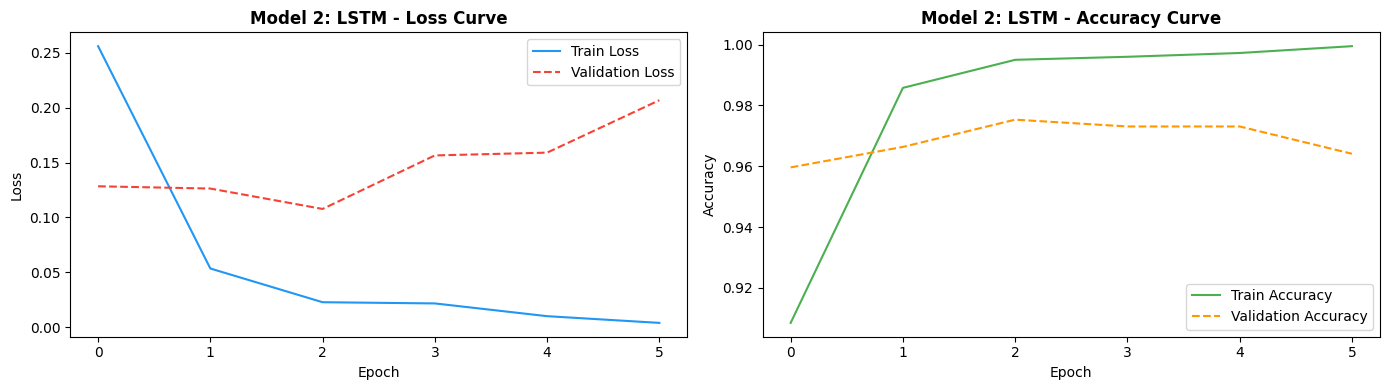

In [ ]:
print("Training Model 2: LSTM...")
t0 = time.time()

history_lstm = lstm_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=get_callbacks(patience=3),
    verbose=1
)

lstm_train_time = time.time() - t0
print(f"\nTraining Time: {lstm_train_time:.1f}s")
plot_history(history_lstm, 'Model 2: LSTM', save_path='history_lstm.png')


  Model 2: LSTM - Evaluation
  Test Accuracy : 0.9857 (98.57%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       966
        Spam       0.99      0.90      0.94       149

    accuracy                           0.99      1115
   macro avg       0.99      0.95      0.97      1115
weighted avg       0.99      0.99      0.99      1115



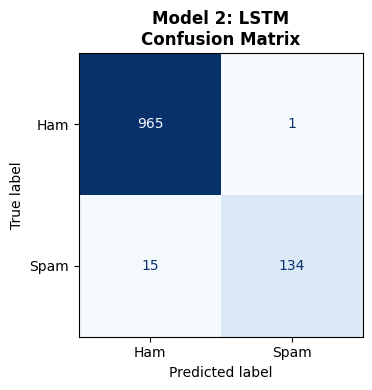

In [ ]:
y_pred_lstm, acc_lstm = evaluate_model(lstm_model, X_test_pad, y_test, 'Model 2: LSTM')

---
### LSTM with Pretrained GloVe (Word2Vec) Embeddings


In [ ]:
print("Loading GloVe glove-wiki-gigaword-50 (50-dim)...")
embedding_model = api.load('glove-wiki-gigaword-50')
GLOVE_DIM = 50

print(f"GloVe loaded. Dimension: {GLOVE_DIM}, Vocab: {len(embedding_model.key_to_index):,}")

Loading GloVe glove-wiki-gigaword-50 (50-dim)...
[==================================================] 100.0% 66.0/66.0MB downloaded
GloVe loaded. Dimension: 50, Vocab: 400,000


In [ ]:
# Build embedding matrix
embedding_matrix = np.zeros((vocab_size, GLOVE_DIM))
found = 0

for word, i in word_index.items():
    if i >= vocab_size:
        continue
    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]
        found += 1

not_found = (vocab_size - 1) - found
print(f"Embedding Matrix Shape  : {embedding_matrix.shape}")
print(f"Words found in GloVe    : {found}")
print(f"Words NOT found (zeros) : {not_found}")
print(f"Vocabulary Coverage     : {found / (vocab_size - 1) * 100:.1f}%")

Embedding Matrix Shape  : (6983, 50)
Words found in GloVe    : 5064
Words NOT found (zeros) : 1918
Vocabulary Coverage     : 72.5%


In [ ]:
lstm_w2v_model = Sequential(name='LSTM_GloVe_Model')

# Pretrained GloVe embedding (frozen)
lstm_w2v_model.add(Embedding(
    input_dim=vocab_size,
    output_dim=GLOVE_DIM,
    weights=[embedding_matrix],
    input_length=MAX_LEN,
    trainable=False,    # Set True to fine-tune GloVe weights
    name='glove_embedding'
))
lstm_w2v_model.add(LSTM(128, return_sequences=True,  name='lstm_1'))
lstm_w2v_model.add(Dropout(0.4))
lstm_w2v_model.add(LSTM(64,  return_sequences=False, name='lstm_2'))
lstm_w2v_model.add(Dropout(0.3))
lstm_w2v_model.add(Dense(64, activation='relu', name='dense_hidden'))
lstm_w2v_model.add(Dropout(0.3))
lstm_w2v_model.add(Dense(1, activation='sigmoid', name='output'))

# Lower learning rate when using pretrained weights
lstm_w2v_model.compile(
    optimizer=Adam(learning_rate=5e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)
lstm_w2v_model.summary()

Model: "LSTM_GloVe_Model"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ glove_embedding (Embedding)     │ ?                      │       349,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_hidden (Dense)            │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 349,150 (1.33 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 349,150 (1.33 MB)

Training Model 3: LSTM + GloVe...
Epoch 1/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - accuracy: 0.9040 - loss: 0.3116 - val_accuracy: 0.9327 - val_loss: 0.2195
Epoch 2/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9556 - loss: 0.1366 - val_accuracy: 0.9417 - val_loss: 0.1775
Epoch 3/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9636 - loss: 0.1125 - val_accuracy: 0.9507 - val_loss: 0.1457
Epoch 4/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9686 - loss: 0.1006 - val_accuracy: 0.9574 - val_loss: 0.1304
Epoch 5/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9711 - loss: 0.0875 - val_accuracy: 0.9529 - val_loss: 0.1279
Epoch 6/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9761 - loss: 0.0734 - val_accuracy: 0.9529 - val_loss: 0.1345
Epoch 7/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9806 - loss: 0.0629 - val_accuracy: 0.9574 - val_loss: 0.1345
Epoch 8/20
63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9828 - loss: 0.0554

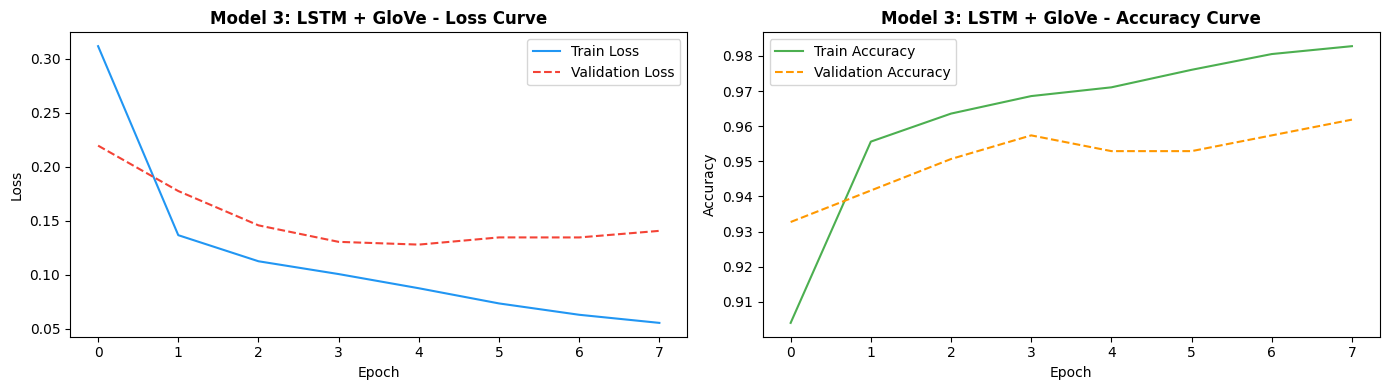

In [ ]:
print("Training Model 3: LSTM + GloVe...")
t0 = time.time()

history_lstm_w2v = lstm_w2v_model.fit(
    X_train_pad, y_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_split=0.1,
    callbacks=get_callbacks(patience=3),
    verbose=1
)

lstm_w2v_train_time = time.time() - t0
print(f"\nTraining Time: {lstm_w2v_train_time:.1f}s")
plot_history(history_lstm_w2v, 'Model 3: LSTM + GloVe', save_path='history_lstm_w2v.png')


  Model 3: LSTM + GloVe - Evaluation
  Test Accuracy : 0.9659 (96.59%)

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      0.99      0.98       966
        Spam       0.92      0.82      0.87       149

    accuracy                           0.97      1115
   macro avg       0.94      0.90      0.92      1115
weighted avg       0.97      0.97      0.97      1115



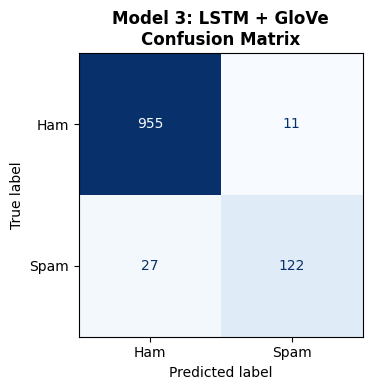

In [ ]:
y_pred_lstm_w2v, acc_lstm_w2v = evaluate_model(
    lstm_w2v_model, X_test_pad, y_test, 'Model 3: LSTM + GloVe'
)

---
## Comparative Analysis: All Three Models

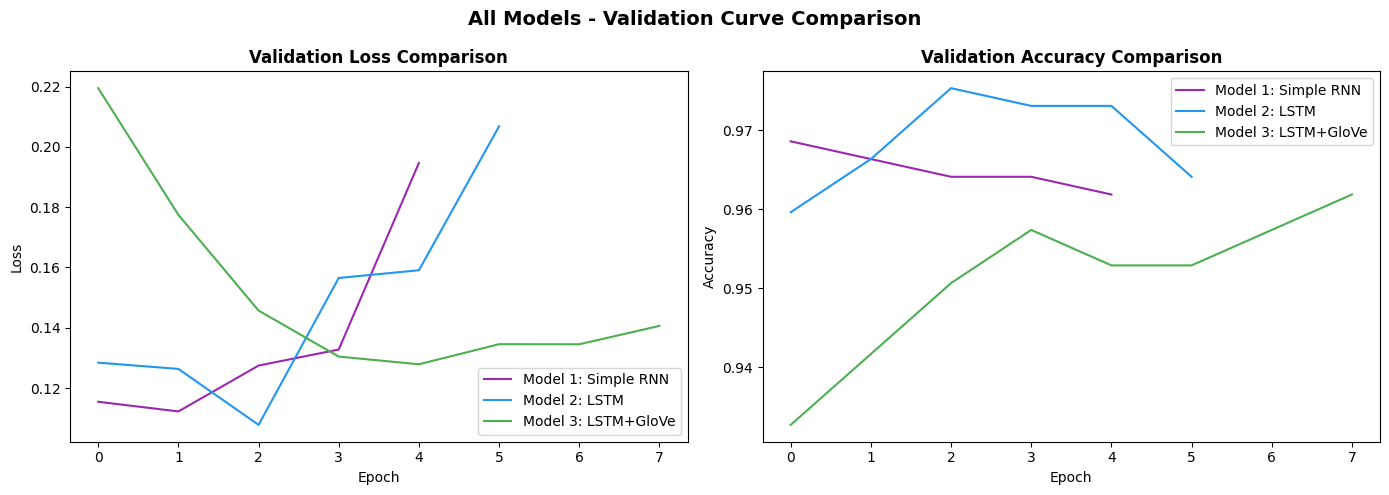

In [ ]:
# Validation curve overlay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
model_histories = [
    (history_rnn,      'Model 1: Simple RNN', '#9C27B0'),
    (history_lstm,     'Model 2: LSTM',       '#2196F3'),
    (history_lstm_w2v, 'Model 3: LSTM+GloVe', '#4CAF50'),
]
for h, name, color in model_histories:
    axes[0].plot(h.history['val_loss'],     label=name, color=color)
    axes[1].plot(h.history['val_accuracy'], label=name, color=color)

axes[0].set_title('Validation Loss Comparison',     fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss');     axes[0].legend()
axes[1].set_title('Validation Accuracy Comparison', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy'); axes[1].legend()

plt.suptitle('All Models - Validation Curve Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Summary performance table
model_names = ['Model 1: Simple RNN', 'Model 2: LSTM', 'Model 3: LSTM+GloVe']
preds       = [y_pred_rnn, y_pred_lstm, y_pred_lstm_w2v]
train_times = [rnn_train_time, lstm_train_time, lstm_w2v_train_time]

rows = []
for name, ypred, tt in zip(model_names, preds, train_times):
    rows.append({
        'Model'         : name,
        'Accuracy'      : f"{accuracy_score(y_test, ypred)*100:.2f}%",
        'Precision'     : f"{precision_score(y_test, ypred)*100:.2f}%",
        'Recall'        : f"{recall_score(y_test, ypred)*100:.2f}%",
        'F1-Score'      : f"{f1_score(y_test, ypred)*100:.2f}%",
        'Train Time (s)': f"{tt:.1f}"
    })

summary_df = pd.DataFrame(rows)
print("\n" + "="*75)
print("  MODEL PERFORMANCE COMPARISON SUMMARY")
print("="*75)
print(summary_df.to_string(index=False))


  MODEL PERFORMANCE COMPARISON SUMMARY
              Model Accuracy Precision Recall F1-Score Train Time (s)
Model 1: Simple RNN   97.67%    96.24% 85.91%   90.78%           12.5
      Model 2: LSTM   98.57%    99.26% 89.93%   94.37%           12.1
Model 3: LSTM+GloVe   96.59%    91.73% 81.88%   86.52%            7.7


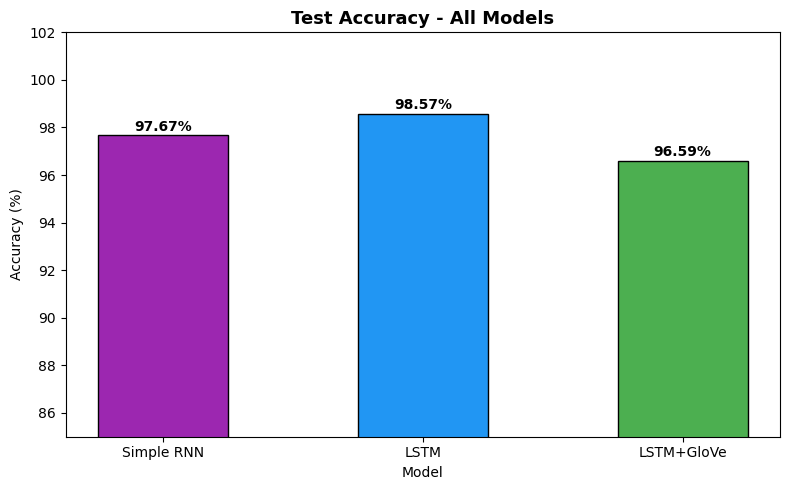

In [ ]:
# Accuracy bar chart
accs        = [accuracy_score(y_test, p) for p in preds]
short_names = ['Simple RNN', 'LSTM', 'LSTM+GloVe']
bar_colors  = ['#9C27B0', '#2196F3', '#4CAF50']

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(short_names, [a*100 for a in accs],
              color=bar_colors, edgecolor='black', width=0.5)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.2,
            f'{acc*100:.2f}%', ha='center', fontweight='bold')
ax.set_ylim(85, 102)
ax.set_title('Test Accuracy - All Models', fontsize=13, fontweight='bold')
ax.set_xlabel('Model'); ax.set_ylabel('Accuracy (%)')
plt.tight_layout()
plt.savefig('accuracy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Error Analysis

In [ ]:
# Rebuild test-aligned dataframe
test_df = pd.DataFrame({
    'original_message': df['message'].values[-len(X_test):],
    'cleaned_message' : X_test,
    'true_label'      : ['spam' if v == 1 else 'ham' for v in y_test],
    'pred_label'      : ['spam' if v == 1 else 'ham' for v in y_pred_lstm_w2v],
}).reset_index(drop=True)

misclassified = test_df[test_df['true_label'] != test_df['pred_label']].reset_index(drop=True)

fp = misclassified[misclassified['true_label'] == 'ham']
fn = misclassified[misclassified['true_label'] == 'spam']

print("Error Analysis - Model 3: LSTM + GloVe")
print("=" * 65)
print(f"Total test samples          : {len(y_test)}")
print(f"Total misclassified         : {len(misclassified)}")
print(f"Misclassification rate      : {len(misclassified)/len(y_test)*100:.2f}%")
print(f"False Positives (Ham->Spam) : {len(fp)}")
print(f"False Negatives (Spam->Ham) : {len(fn)}")

print("\n--- 3 Sample Misclassified Messages ---\n")
for i, row in misclassified.head(3).iterrows():
    print(f"  [{i+1}] Original   : {row['original_message']}")
    print(f"      True Label : {row['true_label'].upper()}")
    print(f"      Predicted  : {row['pred_label'].upper()}")
    if row['true_label'] == 'ham':
        reason = "Ham misclassified as Spam: may contain promotion-like keywords."
    else:
        reason = "Spam missed as Ham: subtle or unusual phrasing not well represented in training."
    print(f"      Reason     : {reason}")
    print()

Error Analysis - Model 3: LSTM + GloVe
Total test samples          : 1115
Total misclassified         : 38
Misclassification rate      : 3.41%
False Positives (Ham->Spam) : 11
False Negatives (Spam->Ham) : 27

--- 3 Sample Misclassified Messages ---

  [1] Original   : In case you wake up wondering where I am, I forgot I have to take care of something for grandma today, should be done before the parade
      True Label : HAM
      Predicted  : SPAM
      Reason     : Ham misclassified as Spam: may contain promotion-like keywords.

  [2] Original   : Wot is u up 2 then bitch?
      True Label : SPAM
      Predicted  : HAM
      Reason     : Spam missed as Ham: subtle or unusual phrasing not well represented in training.

  [3] Original   : Sure, whenever you show the fuck up &gt;:(
      True Label : HAM
      Predicted  : SPAM
      Reason     : Ham misclassified as Spam: may contain promotion-like keywords.



In [ ]:
# Model complexity vs performance
param_counts = [
    rnn_model.count_params(),
    lstm_model.count_params(),
    lstm_w2v_model.count_params()
]

print("Model Complexity vs Performance:")
print("-" * 65)
for name, params, acc, tt in zip(model_names, param_counts, accs, train_times):
    print(f"{name}")
    print(f"  Parameters  : {params:,}")
    print(f"  Accuracy    : {acc*100:.2f}%")
    print(f"  Train Time  : {tt:.1f}s")
    print()

print("Suggested Improvements:")
print("  1. Use class_weight={'ham':1, 'spam':6} to address class imbalance.")
print("  2. Fine-tune GloVe (trainable=True) with a lower learning rate.")
print("  3. Add Bidirectional LSTM for better context from both directions.")
print("  4. Apply data augmentation (back-translation) for minority class.")
print("  5. Experiment with larger GloVe (100d or 200d) for richer representations.")

Model Complexity vs Performance:
-----------------------------------------------------------------
Model 1: Simple RNN
  Parameters  : 457,281
  Accuracy    : 97.67%
  Train Time  : 12.5s

Model 2: LSTM
  Parameters  : 599,361
  Accuracy    : 98.57%
  Train Time  : 12.1s

Model 3: LSTM+GloVe
  Parameters  : 494,431
  Accuracy    : 96.59%
  Train Time  : 7.7s

Suggested Improvements:
  1. Use class_weight={'ham':1, 'spam':6} to address class imbalance.
  2. Fine-tune GloVe (trainable=True) with a lower learning rate.
  3. Add Bidirectional LSTM for better context from both directions.
  4. Apply data augmentation (back-translation) for minority class.
  5. Experiment with larger GloVe (100d or 200d) for richer representations.


---
## GUI for Real-Time Prediction (Gradio)

In [1]:
import gradio as gr

def predict_spam(message: str) -> str:
    """
    Real-time prediction pipeline:
      1. Clean the input message
      2. Tokenize and pad to MAX_LEN
      3. Predict with Model 3 (LSTM + GloVe)
      4. Return label and confidence score
    """
    if not message.strip():
        return "Please enter a message."

    cleaned    = clean_text(message)
    seq        = tokenizer.texts_to_sequences([cleaned])
    padded     = pad_sequences(seq, maxlen=MAX_LEN, padding='post', truncating='post')
    prob       = float(lstm_w2v_model.predict(padded, verbose=0)[0][0])
    label      = 'SPAM' if prob >= 0.5 else 'HAM'
    confidence = prob if label == 'SPAM' else (1 - prob)
    emoji      = 'SPAM DETECTED' if label == 'SPAM' else 'LEGITIMATE MESSAGE'

    return (
        f"Result     : {emoji}\n"
        f"Label      : {label}\n"
        f"Confidence : {confidence * 100:.1f}%\n"
        f"Cleaned    : {cleaned if cleaned else '(empty after cleaning)'}"
    )

demo = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(
        lines=3,
        placeholder="Type or paste an SMS message here...",
        label="SMS Message"
    ),
    outputs=gr.Textbox(label="Prediction Result", lines=5),
    title="SMS Spam Detector - 6CS012 NLP Task",
    description=(
        "Real-time Spam vs Ham SMS classification using LSTM + GloVe Embeddings.\n"
        "Dataset: SMS Spam Collection (5,574 messages) | Herald College, Kathmandu"
    ),
    examples=[
        ["Congratulations! You've won a FREE holiday! Call 08712345678 now!"],
        ["Hey, are you coming to the meeting tomorrow at 3pm?"],
        ["URGENT: Your account has been SUSPENDED. Click here to restore access."],
        ["Ok I'll be home by 8, do you want me to pick up anything?"],
        ["Win FREE tickets! Text WIN to 80086 now. T&Cs apply."],
        ["Mum said dinner is ready, come downstairs."],
    ],
    theme=gr.themes.Soft()
)

# share=True generates a public URL valid for 72 hours
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d502c0e357294d7a1b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
